#### Two questions asked in the paper

1. Given the utterance/price, how would you rate it's expensive?
2. How would you rate the probablity of the item cost [s] dollars?

In [2]:
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns
import ast
import os
import re

In [4]:
# combine data from different runs
# experiments 1
expt_1 = os.listdir("../../data/results_pt_01_14/experiment_1_full/")
expt_1a = [p for p in expt_1 if "1a" in p]
expt_1b = [p for p in expt_1 if "1b" in p]
expt_2 = os.listdir("../../data/results_pt_01_14/experiment_2_full/")
expt_3 = os.listdir("../../data/results_pt_01_14/experiment_3_full/")
expt_3a = [p for p in expt_3 if "3a" in p]
expt_3b = [p for p in expt_3 if "3b" in p]

def process_df(p):
    d = pd.read_csv(p)
    d["model"] = p.split("/")[-1].split("_")[0]
    d["run"] = p.split("/")[-1].split("_")[5]
    d["temperature"] = p.split("/")[-1].split("_")[2]
    return d

def process_1b(d):
    data = pd.read_csv("../../data/experiment_1_full.csv")
    unique_prices = data["price"].unique().tolist()
    d["prices"] = [unique_prices] * len(d)
    return d

df_1a = pd.concat(
    [process_df(os.path.join("../../data/results_pt_01_14/experiment_1_full", p)) for p in expt_1a]
)
df_1b = pd.concat(
    [process_1b(process_df(os.path.join("../../data/results_pt_01_14/experiment_1_full", p))) for p in expt_1b]
)
df_2 = pd.concat(
    [process_df(os.path.join("../../data/results_pt_01_14/experiment_2_full", p)) for p in expt_2]
)
df_3a = pd.concat(
    [process_df(os.path.join("../../data/results_pt_01_14/experiment_3_full", p)) for p in expt_3a]
)
df_3b = pd.concat(
    [process_df(os.path.join("../../data/results_pt_01_14/experiment_3_full", p)) for p in expt_3b]
)

In [5]:
# filter out responses which do not contain floats or are empty
def clean_llm_predictions(r, is_list = False):
    r = str(r)
    float_regex = r"\d*\.\d+|\d+"
    # check that there are float regex matches in r
    match = re.findall(float_regex, r)
    # check if matches are empty and a prediction was made, and the runtime processing didn't return 1000 which was used for erroneous strings
    if (len(match) > 0) and (match[0] != "1000"):
        if not is_list:
            res = match[0]
        else:
            res = match
    else:
        res = None
    return res

In [6]:
df_1a_clean = df_1a.copy()
df_1a_clean["parsed_response_clean"] = df_1a_clean["parsed_response"].apply(lambda r: clean_llm_predictions(r))
df_1a_clean_noNa = df_1a_clean.dropna(subset=["parsed_response_clean"])

df_1b_clean = df_1b.copy()
df_1b_clean["parsed_response_clean"] = df_1b_clean["parsed_response"].apply(lambda r: clean_llm_predictions(r, is_list=True))
df_1b_clean_noNa = df_1b_clean.dropna(subset=["parsed_response_clean"])

df_2_clean = df_2.copy()
df_2_clean["parsed_response_clean"] = df_2_clean["parsed_response"].apply(lambda r: clean_llm_predictions(r))
df_2_clean_noNa = df_2_clean.dropna(subset=["parsed_response_clean"])

df_3a_clean = df_3a.copy()
df_3a_clean["parsed_response_clean"] = df_3a_clean["parsed_response"].apply(lambda r: clean_llm_predictions(r))
df_3a_clean_noNa = df_3a_clean.dropna(subset=["parsed_response_clean"])

df_3b_clean = df_3b.copy()
df_3b_clean["parsed_response_clean"] = df_3b_clean["parsed_response"].apply(lambda r: clean_llm_predictions(r))
df_3b_clean_noNa = df_3b_clean.dropna(subset=["parsed_response_clean"])


In [18]:
df_1b_clean[df_1b_clean["parsed_response_clean"].isna()].value_counts("model")
df_1b_clean['prices'].tolist()[0]

[47,
 48,
 49,
 50,
 51,
 52,
 53,
 497,
 498,
 499,
 500,
 501,
 502,
 503,
 997,
 998,
 999,
 1000,
 1001,
 1002,
 1003,
 4997,
 4998,
 4999,
 5000,
 5001,
 5002,
 5003,
 9997,
 9998,
 9999,
 10000,
 10001,
 10002,
 10003]

In [49]:
# df_1a_clean_noNa.to_csv("../../data/results_pt_01_14/experiment_1a_full.csv", index=False)
# df_1b_clean_noNa.to_csv("../../data/results_pt_01_14/experiment_1b_full.csv", index=False)
# df_2_clean_noNa.to_csv("../../data/results_pt_01_14/experiment_2_full.csv", index=False)
# df_3a_clean_noNa.to_csv("../../data/results_pt_01_14/experiment_3a_full.csv", index=False)
# df_3b_clean_noNa.to_csv("../../data/results_pt_01_14/experiment_3b_full.csv", index=False)

In [22]:
df_1b_clean_noNa

,name,context,price,utterance_template,question_prefix,question_affect,response_prefix,task_1a,task_1b,is_price_space,price_type,price_rounded,closest_price_space,item,parsed_response,model,run,temperature,prices,parsed_response_clean
0,Daniel,Daniel bought a new electric kettle,47,It cost $47.,"A friend asked him,",Was it expensive?,"Daniel said,",Please provide the probability that the Danie...,Please provide the probability that the elect...,False,sharp,50,51,electric kettle,"0.9, 0, 0.01, 0, 0.001, 0, 0.001, 0, 0.0, 0.0",gemini-1.5-pro,iter0,1.0,"[47, 48, 49, 50, 51, 52, 53, 497, 498, 499, 50...","[0.9, 0, 0.01, 0, 0.001, 0, 0.001, 0, 0.0, 0.0]"
1,Frank,Frank bought a new electric kettle,48,It cost $48.,"A friend asked him,",Was it expensive?,"Frank said,",Please provide the probability that the Frank...,Please provide the probability that the elect...,False,sharp,50,51,electric kettle,"0.9, 0, 0.01, 0, 0.001, 0, 0.001, 0, 0.0, 0",gemini-1.5-pro,iter0,1.0,"[47, 48, 49, 50, 51, 52, 53, 497, 498, 499, 50...","[0.9, 0, 0.01, 0, 0.001, 0, 0.001, 0, 0.0, 0]"
2,Harry,Harry bought a new electric kettle,49,It cost $49.,"A friend asked him,",Was it expensive?,"Harry said,",Please provide the probability that the Harry...,Please provide the probability that the elect...,True,sharp,50,51,electric kettle,"0.9, 0.01, 0.01, 0.0, 0.001, 0, 0.001, 0.0, 0....",gemini-1.5-pro,iter0,1.0,"[47, 48, 49, 50, 51, 52, 53, 497, 498, 499, 50...","[0.9, 0.01, 0.01, 0.0, 0.001, 0, 0.001, 0.0, 0..."
3,Zach,Zach bought a new electric kettle,50,It cost $50.,"A friend asked him,",Was it expensive?,"Zach said,",Please provide the probability that the Zach ...,Please provide the probability that the elect...,True,round,50,50,electric kettle,"1.0, 0.0, 0.01, 0.0, 0.01, 0, 0.001, 0.0, 0.00...",gemini-1.5-pro,iter0,1.0,"[47, 48, 49, 50, 51, 52, 53, 497, 498, 499, 50...","[1.0, 0.0, 0.01, 0.0, 0.01, 0, 0.001, 0.0, 0.0..."
4,Ethan,Ethan bought a new electric kettle,50,It cost $50.,"A friend asked him,",Was it expensive?,"Ethan said,",Please provide the probability that the Ethan...,Please provide the probability that the elect...,True,round,50,50,electric kettle,"1, 0.0, 0.01, 0, 0.01, 0, 0.001, 0.0, 0.0, 0.0",gemini-1.5-pro,iter0,1.0,"[47, 48, 49, 50, 51, 52, 53, 497, 498, 499, 50...","[1, 0.0, 0.01, 0, 0.01, 0, 0.001, 0.0, 0.0, 0.0]"
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
115,Fred,Fred bought a new laptop,10000,It cost $10000.,"A friend asked him,",Was it expensive?,"Fred said,",Please provide the probability that the Fred ...,Please provide the probability that the lapto...,True,round,10000,10000,laptop,"0, 0, 0, 0, 0, 0, 0.1, 0, 1, 0",gpt-4o-mini,iter0,1.0,"[47, 48, 49, 50, 51, 52, 53, 497, 498, 499, 50...","[0, 0, 0, 0, 0, 0, 0.1, 0, 1, 0]"
116,Tom,Tom bought a new laptop,10000,It cost $10000.,"A friend asked him,",Was it expensive?,"Tom said,",Please provide the probability that the Tom t...,Please provide the probability that the lapto...,True,round,10000,10000,laptop,"0, 0, 0, 0, 0.01, 0.01, 0.1, 0.01, 0.9, 0",gpt-4o-mini,iter0,1.0,"[47, 48, 49, 50, 51, 52, 53, 497, 498, 499, 50...","[0, 0, 0, 0, 0.01, 0.01, 0.1, 0.01, 0.9, 0]"
117,David,David bought a new laptop,10001,It cost $10001.,"A friend asked him,",Was it expensive?,"David said,",Please provide the probability that the David...,Please provide the probability that the lapto...,False,sharp,10000,10001,laptop,"0, 0, 0, 0, 0, 0.01, 0.01, 0, 0.1, 0.8",gpt-4o-mini,iter0,1.0,"[47, 48, 49, 50, 51, 52, 53, 497, 498, 499, 50...","[0, 0, 0, 0, 0, 0.01, 0.01, 0, 0.1, 0.8]"
118,Gary,Gary bought a new laptop,10002,It cost $10002.,"A friend asked him,",Was it expensive?,"Gary said,",Please provide the probability that the Gary ...,Please provide the probability that the lapto...,False,sharp,10000,10001,laptop,"0.0, 0.01, 0, 0.01, 0.1, 0.01, 0, 0, 0.9, 0.01",gpt-4o-mini,iter0,1.0,"[47, 48, 49, 50, 51, 52, 53, 497, 498, 499, 50...","[0.0, 0.01, 0, 0.01, 0.1, 0.01, 0, 0

In [30]:
## Fig 2A; for this we use results from experiment 1b (probs of each s for each u)

# Exploding values into columns
def spread_parsed_response(row):
    try:
        row["parsed_response_clean"] = [float(f) for f in row["parsed_response_clean"].replace("[", "").replace("]", "").split(",")]
        row["prices"] = ["50", "51", "500", "501", "1000", "1001", "5000", "5001", "10000", "10001"]
    except:
        row["parsed_response_clean"] = [float(f) for f in row["parsed_response_clean"]]
        row["prices"] = ["50", "51", "500", "501", "1000", "1001", "5000", "5001", "10000", "10001"]
    # print([(price, value) for price, value in zip(row['prices'], row['parsed_response_clean'])])
    return {f"price_{price}": value for price, value in zip(row['prices'], row['parsed_response_clean'])}

# Apply the function row-wise to create new columns
spread_df_1b = df_1b_clean_noNa.apply(spread_parsed_response, axis=1, result_type='expand')

# Combine with the original dataframe if needed
spread_df_1b_annotated = pd.concat([df_1b_clean_noNa, spread_df_1b], axis=1)

# # Save or print
spread_df_1b_annotated.rename(columns={"price": "uttered_price"}, inplace=True)

# # renormalize by trial by run
humans_1b = pd.read_csv("../../human_data/experiment1-normalized.csv")
humans_1b_prices = ["price_" + str(p) for p in humans_1b["state"].unique().tolist()]
price_columns = [col for col in spread_df_1b_annotated.columns if col.startswith("price_")]
price_columns = [p for p in price_columns if (p != "price_type") & (p != "price_rounded") & (p in humans_1b_prices)]
# Normalize each row by dividing by the row sum
spread_df_1b_annotated[price_columns] = spread_df_1b_annotated[price_columns].div(spread_df_1b_annotated[price_columns].sum(axis=1), axis=0)
# keep only the humans_1b_prices columns that start with price_
spread_df_1b_selected = spread_df_1b_annotated[["model", "run", "uttered_price", "temperature", "item", "price_type"] + price_columns]
spread_df_1b_selected
# spread_df_1b_selected.to_csv("../../data/results_helix/experiment_1b_spread.csv")
 

,model,run,uttered_price,temperature,item,price_type,price_50,price_51,price_500,price_501,price_1000,price_1001,price_5000,price_5001,price_10000,price_10001
0,gemini-1.5-pro,iter0,47,1.0,electric kettle,sharp,0.986842,0.000000,0.010965,0.000000,0.001096,0.000000,0.001096,0.000000,0.000000,0.000000
1,gemini-1.5-pro,iter0,48,1.0,electric kettle,sharp,0.986842,0.000000,0.010965,0.000000,0.001096,0.000000,0.001096,0.000000,0.000000,0.000000
2,gemini-1.5-pro,iter0,49,1.0,electric kettle,sharp,0.976033,0.010845,0.010845,0.000000,0.001084,0.000000,0.001084,0.000000,0.000108,0.000000
3,gemini-1.5-pro,iter0,50,1.0,electric kettle,round,0.978474,0.000000,0.009785,0.000000,0.009785,0.000000,0.000978,0.000000,0.000978,0.000000
4,gemini-1.5-pro,iter0,50,1.0,electric kettle,round,0.979432,0.000000,0.009794,0.000000,0.009794,0.000000,0.000979,0.000000,0.000000,0.000000
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
115,gpt-4o-mini,iter0,10000,1.0,laptop,round,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,0.090909,0.000000,0.909091,0.000000
116,gpt-4o-mini,iter0,10000,1.0,laptop,round,0.000000,0.000000,0.000000,0.000000,0.009709,0.009709,0.097087,0.009709,0.873786,0.000000
117,gpt-4o-mini,iter0,10001,1.0,laptop,sharp,0.000000,0.000000,0.000000,0.000000,0.000000,0.010870,0.010870,0.000000,0.108696,0.869565
118,gpt-4o-mini,iter0,10002,1.0,laptop,sharp,0.000000,0.009615,0.000000,0.009615,0.096154,0.009615,0.000000,0.000000,0.865385,0.009615


In [32]:
# make a lomg df
df_1b_long = pd.melt(spread_df_1b_selected, id_vars=["run", "temperature", "model", "uttered_price", "item", "price_type"], value_vars=price_columns)
df_1b_long.rename(columns={"variable": "price_value", "value": "probability"}, inplace=True)
df_1b_long["price_value"] = df_1b_long["price_value"].str.replace("price_", "").astype(int)
df_1b_long

# align llm results with human results
humans_1b = pd.read_csv("../../human_data/experiment1-normalized.csv")
humans_1b_prices = humans_1b["state"].unique().tolist()
# align human and llm results by price, utterance, item 
df_1b_aligned = df_1b_long.merge(humans_1b, left_on=["price_value", "uttered_price", "item"], right_on=["state", "utteranceExact", "domain"], how="inner")
df_1b_aligned

# df_1b_aligned.to_csv("../../data/results_helix/experiment_1b_wHuman.csv")

# average over utteance-state pairs
df_1b_aligned_summary = df_1b_aligned.groupby(["model", "temperature", "item", "uttered_price", "state"]).agg({"probability": "mean", "stateProb": "mean"}).reset_index()

In [54]:
def categorize_predictions(row):
    state = row["state"]
    utterance = row["uttered_price"]
    if state == utterance:
        interpretation = "exact"
    elif abs(state - utterance) < 5:
        interpretation = "fuzzy"
    elif utterance > state:
        interpretation = "hyperbolic"
    else:
        interpretation = "other"

    return interpretation
df_1b_aligned_summary["interpretationType"] = df_1b_aligned_summary.apply(categorize_predictions, axis=1)
df_1b_aligned_summary
# categorize the type of utterance-state pair
# df_1b_aligned_summary.to_csv("../../data/results_helix/experiment_1b_wHuman_summary.csv")

,model,temperature,item,uttered_price,state,probability,stateProb,interpretationType
0,claude-3-5-sonnet-20241022,1.0,electric kettle,47,50,0.546774,0.386703,fuzzy
1,claude-3-5-sonnet-20241022,1.0,electric kettle,47,51,0.453226,0.407513,fuzzy
2,claude-3-5-sonnet-20241022,1.0,electric kettle,48,50,0.633333,0.333254,fuzzy
3,claude-3-5-sonnet-20241022,1.0,electric kettle,48,51,0.366667,0.455067,fuzzy
4,claude-3-5-sonnet-20241022,1.0,electric kettle,49,50,0.541667,0.355869,fuzzy
...,...,...,...,...,...,...,...,...
625,gpt-4o-mini,1.0,watch,10001,51,0.946970,0.110808,hyperbolic
626,gpt-4o-mini,1.0,watch,10002,50,0.061505,0.034266,hyperbolic
627,gpt-4o-mini,1.0,watch,10002,51,0.938495,0.035582,hyperbolic
628,gpt-4o-mini,1.0,watch,10003,50,0.063636,0.069279,hyperbolic


<Figure size 1200x800 with 0 Axes>

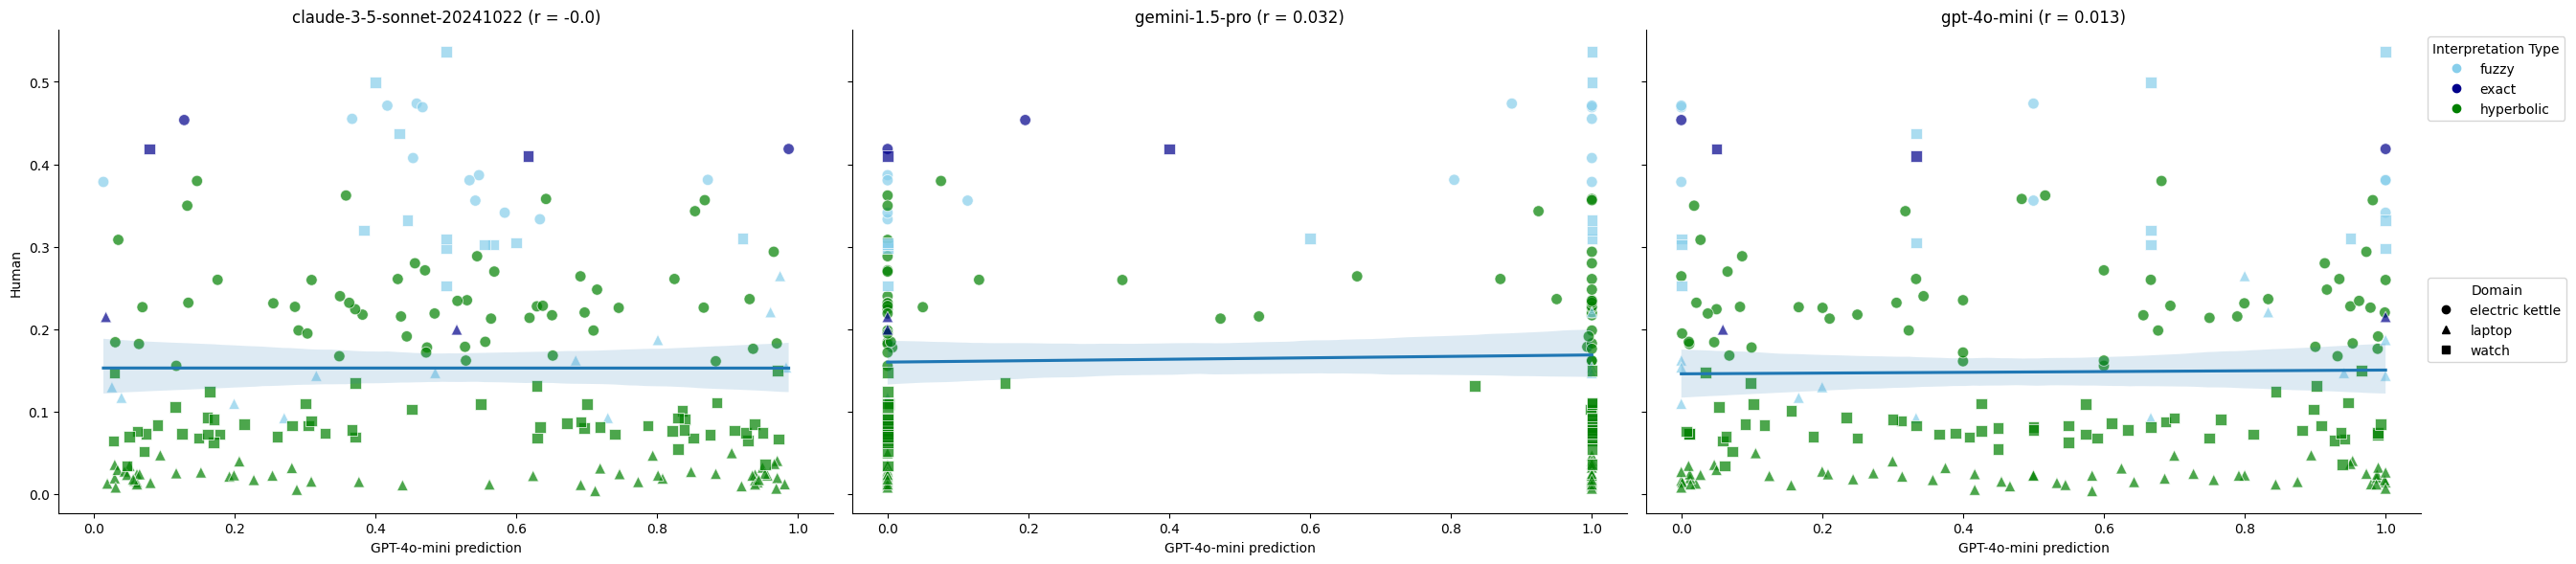

In [60]:
import matplotlib.pyplot as plt
import seaborn as sns
import matplotlib.lines as mlines

# Define color palette and markers
color_palette = {
    'exact': 'darkblue',
    'fuzzy': 'skyblue',
    'hyperbolic': 'green',
    'other': 'gray'
}

markers = {
    'electric kettle': 'o',  # Circle
    'laptop': '^',  # Triangle
    'watch': 's'  # Square
}

# Create the correlation plot using FacetGrid
plt.figure(figsize=(12, 8))
plot_grid = sns.FacetGrid(data=df_1b_aligned_summary, col='model', col_wrap=3, height=6, aspect=1.5)

# Define a custom plotting function to add scatter and regression lines per facet
def scatter_with_reg(data, **kwargs):
    sns.scatterplot(
        data=data, 
        x='probability', 
        y='stateProb', 
        style='item', 
        hue='interpretationType', 
        palette=color_palette, 
        markers=markers, 
        s=70, alpha=0.7, 
        **kwargs
    )
    sns.regplot(
        data=data, 
        x='probability', 
        y='stateProb', 
        scatter=False, 
        ci=95, 
        # color='gray', 
        **kwargs
    )

# Map the custom function to the FacetGrid
plot_grid.map_dataframe(scatter_with_reg)

# Set plot labels and titles
plot_grid.set_axis_labels('GPT-4o-mini prediction', 'Human')
plot_grid.set_titles(col_template="{col_name}")

# Calculate and display correlation coefficient for each model
for ax, model in zip(plot_grid.axes.flat, df_1b_aligned_summary['model'].unique()):
    subset = df_1b_aligned_summary[df_1b_aligned_summary['model'] == model]
    correlation_coefficient = subset['probability'].corr(subset['stateProb'])
    ax.set_title(f"{model} (r = {round(correlation_coefficient, 3)})")

# Add legends
legend_labels = df_1b_aligned_summary['interpretationType'].unique()
legend_handles = [mlines.Line2D([], [], color=color_palette[label], marker='o', linestyle='None', markersize=6, label=label) for label in legend_labels]
legend1 = plt.legend(handles=legend_handles, title='Interpretation Type', bbox_to_anchor=(1.0, 1), loc='upper left')
plt.gca().add_artist(legend1)

domain_labels = df_1b_aligned_summary['item'].unique()
domain_handles = [mlines.Line2D([], [], color='black', marker=markers[label], linestyle='None', markersize=6, label=label) for label in domain_labels]
plt.legend(handles=domain_handles, title='Domain', bbox_to_anchor=(1.0, 0.5), loc='upper left')

# Adjust layout
plt.tight_layout()
plt.show()


#### Figure 4B

In [73]:
def process_df_4b(df):
    # df["domain"] = ["electric kettle"]*60 + ["laptop"]*60 + ["watch"]*60
    # df['numbers'] = df['scenarios'].str.findall(r'\d+')
    df['state'] = df['state_template'].apply(lambda x: re.findall(r'\d+', x)[0])
    # df = df.drop(columns=['numbers'])
    # df = df.drop(columns=['scenarios'])
    # df["affectProb"] = experiment_ratings
    df['state'] = df['state'].astype(int)
    df['utterance'] = df['price'].astype(int)
    df['parsed_response_clean'] = df['parsed_response_clean'].astype(float)
    df['stateType'] = df.apply(lambda row: 'round' if row['state'] % 10 == 0 else 'sharp', axis=1)
    # df['utteranceType'] = df.apply(lambda row: 'round' if row['utterance'] % 10 == 0 else 'sharp', axis=1)
    df['stateRounded'] = df['state'].apply(lambda x: round(x, -1))
    df['utteranceRounded'] = df['utterance'].apply(lambda x: round(x, -1))
    # df = df.drop(columns=['stateType', 'utteranceType'])
    # df = df.rename(columns={"utterance": "utteranceRounded", "state": "stateRounded"})
    return df

In [80]:
# preprocess the df from experiment 2 for plotting
df_e2_4b = process_df_4b(df_2_clean_noNa)
print(df_e2_4b["stateRounded"].unique())
print(df_e2_4b["utteranceRounded"].unique())
df_4b_literal = df_e2_4b[df_e2_4b["stateRounded"] == df_e2_4b["utteranceRounded"]]

df_4b_literal_grouped = df_4b_literal.groupby(["model", "item", "stateRounded"]).mean("parsed_response_clean").reset_index()

# df_4b_v2_literal_grouped.to_csv("df_4b_v2_literal_grouped.csv", index=False)

df_4b_hyperbole = df_e2_4b[df_e2_4b["stateRounded"] < df_e2_4b["utteranceRounded"]]

df_4b_v2_hyperbole_grouped = df_4b_hyperbole.groupby(["model", "item", "stateRounded"]).mean("parsed_response_clean").reset_index()
df_4b_v2_hyperbole_grouped
# df_4b_v2_hyperbole_grouped.to_csv("df_4b_v2_hyperbole_grouped.csv", index=False)

/var/folders/fn/6ct_6l112376k8288ws7798m0000gn/T/ipykernel_96477/2857339370.py:4: SettingWithCopyWarning: 
A value is trying to be set on a copy of a slice from a DataFrame.
Try using .loc[row_indexer,col_indexer] = value instead

See the caveats in the documentation: https://pandas.pydata.org/pandas-docs/stable/user_guide/indexing.html#returning-a-view-versus-a-copy
  df['state'] = df['state_template'].apply(lambda x: re.findall(r'\d+', x)[0])
/var/folders/fn/6ct_6l112376k8288ws7798m0000gn/T/ipykernel_96477/2857339370.py:8: SettingWithCopyWarning: 
A value is trying to be set on a copy of a slice from a DataFrame.
Try using .loc[row_indexer,col_indexer] = value instead

See the caveats in the documentation: https://pandas.pydata.org/pandas-docs/stable/user_guide/indexing.html#returning-a-view-versus-a-copy
  df['state'] = df['state'].astype(int)
/var/folders/fn/6ct_6l112376k8288ws7798m0000gn/T/ipykernel_96477/2857339370.py:9: SettingWithCopyWarning: 
A value is trying to be set on a c

[   50   500  1000  5000 10000]
[   50   500  1000  5000 10000]


/var/folders/fn/6ct_6l112376k8288ws7798m0000gn/T/ipykernel_96477/2857339370.py:11: SettingWithCopyWarning: 
A value is trying to be set on a copy of a slice from a DataFrame.
Try using .loc[row_indexer,col_indexer] = value instead

See the caveats in the documentation: https://pandas.pydata.org/pandas-docs/stable/user_guide/indexing.html#returning-a-view-versus-a-copy
  df['stateType'] = df.apply(lambda row: 'round' if row['state'] % 10 == 0 else 'sharp', axis=1)
/var/folders/fn/6ct_6l112376k8288ws7798m0000gn/T/ipykernel_96477/2857339370.py:13: SettingWithCopyWarning: 
A value is trying to be set on a copy of a slice from a DataFrame.
Try using .loc[row_indexer,col_indexer] = value instead

See the caveats in the documentation: https://pandas.pydata.org/pandas-docs/stable/user_guide/indexing.html#returning-a-view-versus-a-copy
  df['stateRounded'] = df['state'].apply(lambda x: round(x, -1))
/var/folders/fn/6ct_6l112376k8288ws7798m0000gn/T/ipykernel_96477/2857339370.py:14: SettingWithCo

,model,item,stateRounded,price,is_price_space,price_rounded,closest_price_space,parsed_response_clean,state,utterance,utteranceRounded
0,claude-3-5-sonnet-20241022,electric kettle,50,4125.000000,0.375,4125.000000,4125.750000,0.227715,50.0,4125.000000,4125.000000
1,claude-3-5-sonnet-20241022,electric kettle,500,5333.333333,0.375,5333.333333,5334.083333,0.686016,500.0,5333.333333,5333.333333
2,claude-3-5-sonnet-20241022,electric kettle,1000,7500.000000,0.375,7500.000000,7500.750000,0.821758,1000.0,7500.000000,7500.000000
3,claude-3-5-sonnet-20241022,electric kettle,5000,10000.000000,0.375,10000.000000,10000.750000,0.840898,5000.0,10000.000000,10000.000000
4,claude-3-5-sonnet-20241022,laptop,50,4125.000000,0.375,4125.000000,4125.750000,0.486865,50.0,4125.000000,4125.000000
5,claude-3-5-sonnet-20241022,laptop,500,5333.333333,0.375,5333.333333,5334.083333,0.387930,500.0,5333.333333,5333.333333
6,claude-3-5-sonnet-20241022,laptop,1000,7500.000000,0.375,7500.000000,7500.750000,0.496133,1000.0,7500.000000,7500.000000
7,claude-3-5-sonnet-20241022,laptop,5000,10000.000000,0.375,10000.000000,10000.750000,0.730781,5000.0,10000.000000,10000.000000
8,claude-3-5-sonnet-20241022,watch,50,4125.000000,0.375,4125.000000,4125.750000,0.532441,50.0,4125.000000,4125.000000
9,claude-3-5-sonnet-20241022,watch,500,5333.333333,0.375,5333.333333,5334.083333,0.536042,500.0,5333.333333,5333.333333


In [84]:
df_e2_4b_subset = df_e2_4b[["model", "item", "stateRounded", "utteranceRounded", "parsed_response_clean"]]
df_e2_4b_subset = df_e2_4b_subset.rename(columns={"parsed_response_clean": "affectProb"})

In [92]:
df_2_human = pd.read_csv("../../human_data/experiment2-raw.csv")

# remove the columns "workerID", "utteranceExact", "utteranceType", "stateExact", "stateType", "order" in df_2_human
df_2_human = df_2_human.drop(["workerID", "utteranceExact", "utteranceType", "stateExact", "stateType", "order"], axis=1)
df_2_human["model"] = "human"
df_2_human = df_2_human.rename(columns={"domain": "item"})


In [85]:
def code_condition(r):
    if r["stateRounded"] == r["utteranceRounded"]:
        return "literal"
    elif r["stateRounded"] < r["utteranceRounded"]:
        return "hyperbole"
    else:
        return "other"

In [103]:
df_2_4b_plot = pd.concat([df_e2_4b_subset, df_2_human])

# show the lines that have stateRounded == utteranceRounded
df_2_4b_plot["condition"] = df_2_4b_plot.apply(lambda r: code_condition(r), axis=1)

# group by item and stateRounded for df_2_human_literal and then get the mean of the ratings for each group
df_2_4b_plot_grouped = df_2_4b_plot.groupby(["item", "stateRounded", "model", "condition"]).mean().reset_index()

df_2_4b_plot_grouped["stateRounded"] = df_2_4b_plot_grouped["stateRounded"].astype(str)
df_2_4b_plot_grouped["item"] = df_2_4b_plot_grouped["item"].apply(lambda s: s.strip())

In [104]:
df_2_4b_plot_grouped["item"].unique()

array(['electric kettle', 'laptop', 'watch'], dtype=object)

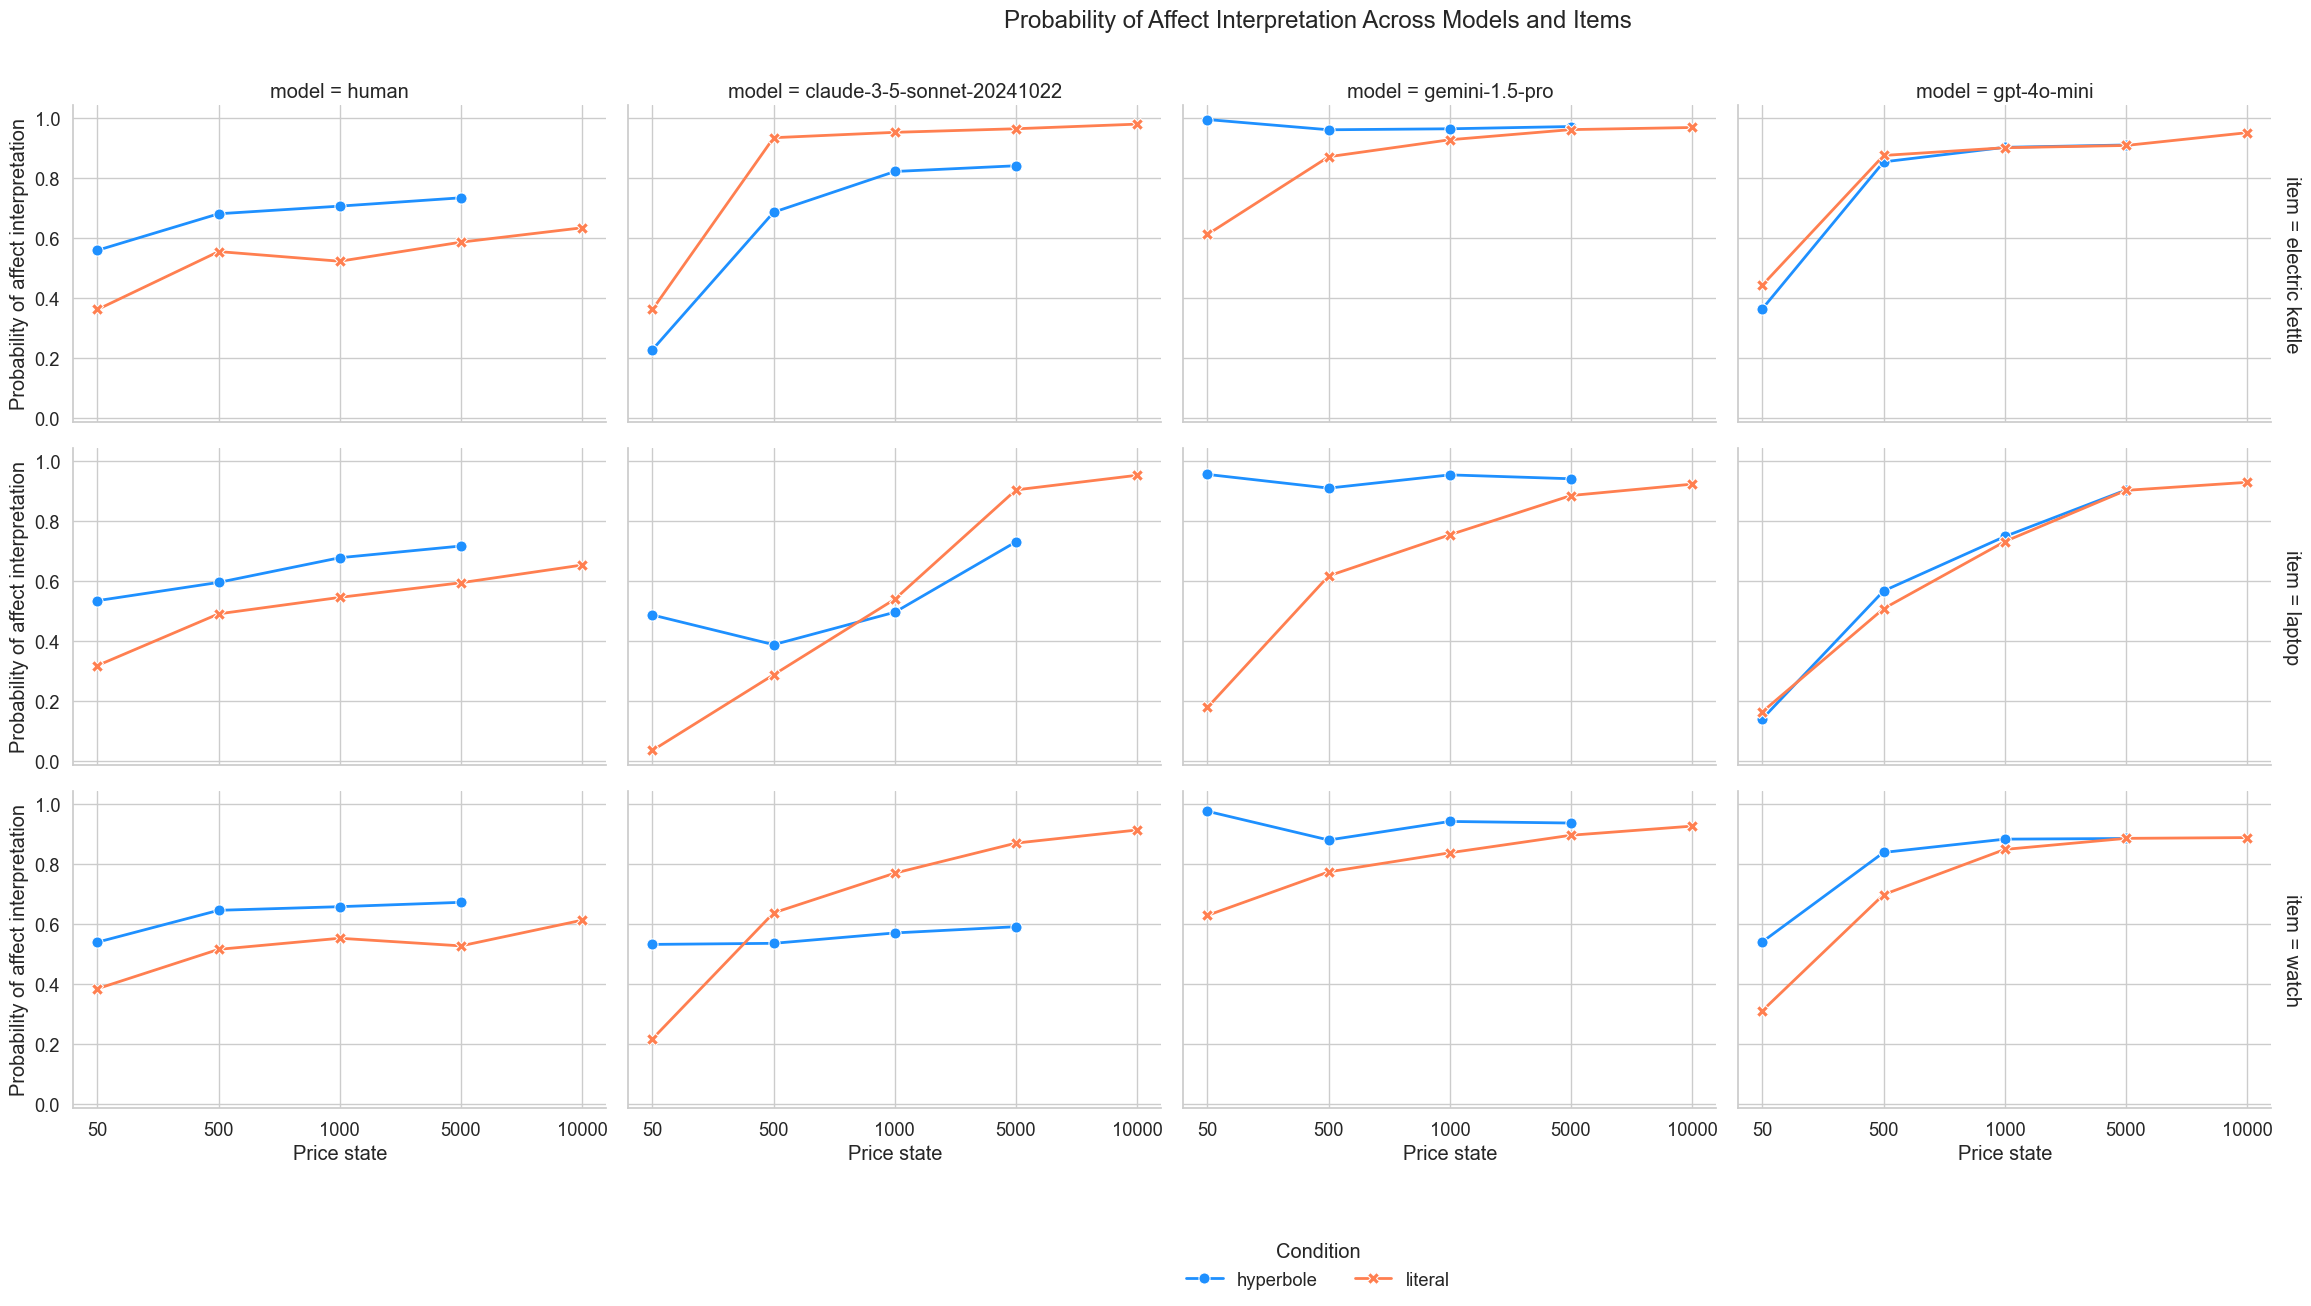

In [105]:
import pandas as pd
import seaborn as sns
import matplotlib.pyplot as plt

# Load the data
df = df_2_4b_plot_grouped #pd.read_csv("path_to_your_data.csv")  # Replace with your actual file path

# Define plot aesthetics
sns.set(style="whitegrid", font_scale=1.2)
colors = {
    'hyperbole': 'dodgerblue', 
    'literal': 'coral'
}

markers = {
    'hyperbole': 'v',  # Downward triangle
    'literal': 'o'  # Circle
}

# Create the facet grid for the plot
g = sns.FacetGrid(
    data=df,
    col="model",
    row="item",
    height=4,
    aspect=1.5,
    margin_titles=True,
    sharey=True,
    sharex=True
)

# Add line plots for each condition
g.map_dataframe(
    sns.lineplot,
    x="stateRounded",
    y="affectProb",
    hue="condition",
    style="condition",
    markers=True,
    dashes=False,
    palette=colors,
    linewidth=2,
    markersize=8
)

# Customize plot
g.set_axis_labels("Price state", "Probability of affect interpretation")
g.add_legend(title="Condition", loc='lower center', bbox_to_anchor=(0.5, -0.1), ncol=2)

# Adjust titles and spacing
for ax in g.axes.flat:
    ax.set_xticks(["50", "500", "1000", "5000", "10000"])

plt.subplots_adjust(top=0.9)
g.fig.suptitle("Probability of Affect Interpretation Across Models and Items")

# Show plot
plt.show()


#### Figure 3a

In [68]:
# computed the probability of a participant interpreting an utterance u as hyperbolic by summing up ratings for each interpreted price state s where u > s
# collapse across sharp and round utterances by rounding the utterance values
df_1b_long["uttered_price_rounded"] = df_1b_long["uttered_price"].apply(lambda x: round(x, -1))
df_1b_long_hyperbolic_interpretation = df_1b_long[df_1b_long["uttered_price_rounded"] > df_1b_long["price_value"]]
# print(df_1b_long_hyperbolic_interpretation[df_1b_long_hyperbolic_interpretation["probability"] > 1])
# print(df_1b_long_hyperbolic_interpretation.head())
# average over the different sharp and round utterances for each state
df_1b_long_hyperbolic_interpretation_rounded = df_1b_long_hyperbolic_interpretation.groupby(["model", "temperature", "item", "run", "uttered_price_rounded", "price_value"]).agg({"probability": "mean"}).reset_index()
df_1b_long_hyperbolic_interpretation_summed = df_1b_long_hyperbolic_interpretation_rounded.groupby(["model", "temperature", "item", "run", "uttered_price_rounded"]).agg({"probability": "sum"}).reset_index()
print(df_1b_long_hyperbolic_interpretation_summed[df_1b_long_hyperbolic_interpretation_summed["probability"] > 1])
# average over runs
df_1b_long_hyperbolic_interpretation_summed = df_1b_long_hyperbolic_interpretation_summed.groupby(["model", "temperature", "item", "uttered_price_rounded"]).agg({"probability": "mean"}).reset_index()

Empty DataFrame
Columns: [model, temperature, item, run, uttered_price_rounded, probability]
Index: []


In [49]:
df_experiment1a = pd.read_csv("../../human_data/experiment1-normalized.csv")
df_experiment1a = df_experiment1a.drop(columns=["utteranceType", "utteranceExact", "utteranceRounded", "stateType", "stateRounded", "order", "affectProb"])

# show the lines that have state < utterance and reindex the dataframe
df_experiment1a["utterance_rounded"] = df_experiment1a["utterance"].apply(lambda x: round(x, -1))
df_experiment1a_hyperbole = df_experiment1a[df_experiment1a["state"] < df_experiment1a["utterance_rounded"]].reset_index(drop=True)

# rename the columns to item, utterance, prices, rating
df_experiment1a_hyperbole = df_experiment1a_hyperbole.rename(columns={"domain": "item", "state": "prices", "stateProb": "rating"})
df_experiment1a_hyperbole
# let the second columns show prices and the third show utterance
df_experiment1a_hyperbole = df_experiment1a_hyperbole[["workerID", "item", "prices", "utterance_rounded", "rating"]]
df_experiment1a_hyperbole

#  group by item and then by utterance and then sum up the ratings for all prices
df_experiment1a_hyperbole_grouped = df_experiment1a_hyperbole.groupby(["workerID", "item", "utterance_rounded"]).sum().reset_index()

In [69]:
df_1b_long_hyperbolic_interpretation_summed

,model,temperature,item,uttered_price_rounded,probability
0,claude-3-5-sonnet-20241022,1.0,electric kettle,500,0.567767
1,claude-3-5-sonnet-20241022,1.0,electric kettle,1000,0.670806
2,claude-3-5-sonnet-20241022,1.0,electric kettle,5000,0.827263
3,claude-3-5-sonnet-20241022,1.0,electric kettle,10000,0.874391
4,claude-3-5-sonnet-20241022,1.0,laptop,500,0.033585
5,claude-3-5-sonnet-20241022,1.0,laptop,1000,0.098014
6,claude-3-5-sonnet-20241022,1.0,laptop,5000,0.467352
7,claude-3-5-sonnet-20241022,1.0,laptop,10000,0.702626
8,claude-3-5-sonnet-20241022,1.0,watch,500,0.153832
9,claude-3-5-sonnet-20241022,1.0,watch,1000,0.150463


In [70]:
# avergae over participants
df_experiment1a_hyperbole_grouped_agg = df_experiment1a_hyperbole_grouped.groupby(["item", "utterance_rounded"]).agg({"rating": "mean"}).reset_index()
df_experiment1a_hyperbole_grouped_agg["model"] = "human"
df_experiment1a_hyperbole_grouped_agg = df_experiment1a_hyperbole_grouped_agg.rename(columns={"rating": "probability"})
# combine llm and human data
df_1b_long_hyperbolic_interpretation_summed = df_1b_long_hyperbolic_interpretation_summed.rename(columns={"uttered_price_rounded": "utterance_rounded"})[['model', 'item', 'utterance_rounded', 'probability']]
df_hyperbole_3a = pd.concat([df_experiment1a_hyperbole_grouped_agg, df_1b_long_hyperbolic_interpretation_summed])

/var/folders/fn/6ct_6l112376k8288ws7798m0000gn/T/ipykernel_64614/1077241250.py:17: SettingWithCopyWarning: 
A value is trying to be set on a copy of a slice from a DataFrame.
Try using .loc[row_indexer,col_indexer] = value instead

See the caveats in the documentation: https://pandas.pydata.org/pandas-docs/stable/user_guide/indexing.html#returning-a-view-versus-a-copy
  filtered_data['utterance'] = filtered_data['utterance_rounded'].astype(str)
/var/folders/fn/6ct_6l112376k8288ws7798m0000gn/T/ipykernel_64614/1077241250.py:17: SettingWithCopyWarning: 
A value is trying to be set on a copy of a slice from a DataFrame.
Try using .loc[row_indexer,col_indexer] = value instead

See the caveats in the documentation: https://pandas.pydata.org/pandas-docs/stable/user_guide/indexing.html#returning-a-view-versus-a-copy
  filtered_data['utterance'] = filtered_data['utterance_rounded'].astype(str)
/var/folders/fn/6ct_6l112376k8288ws7798m0000gn/T/ipykernel_64614/1077241250.py:17: SettingWithCopyWarn

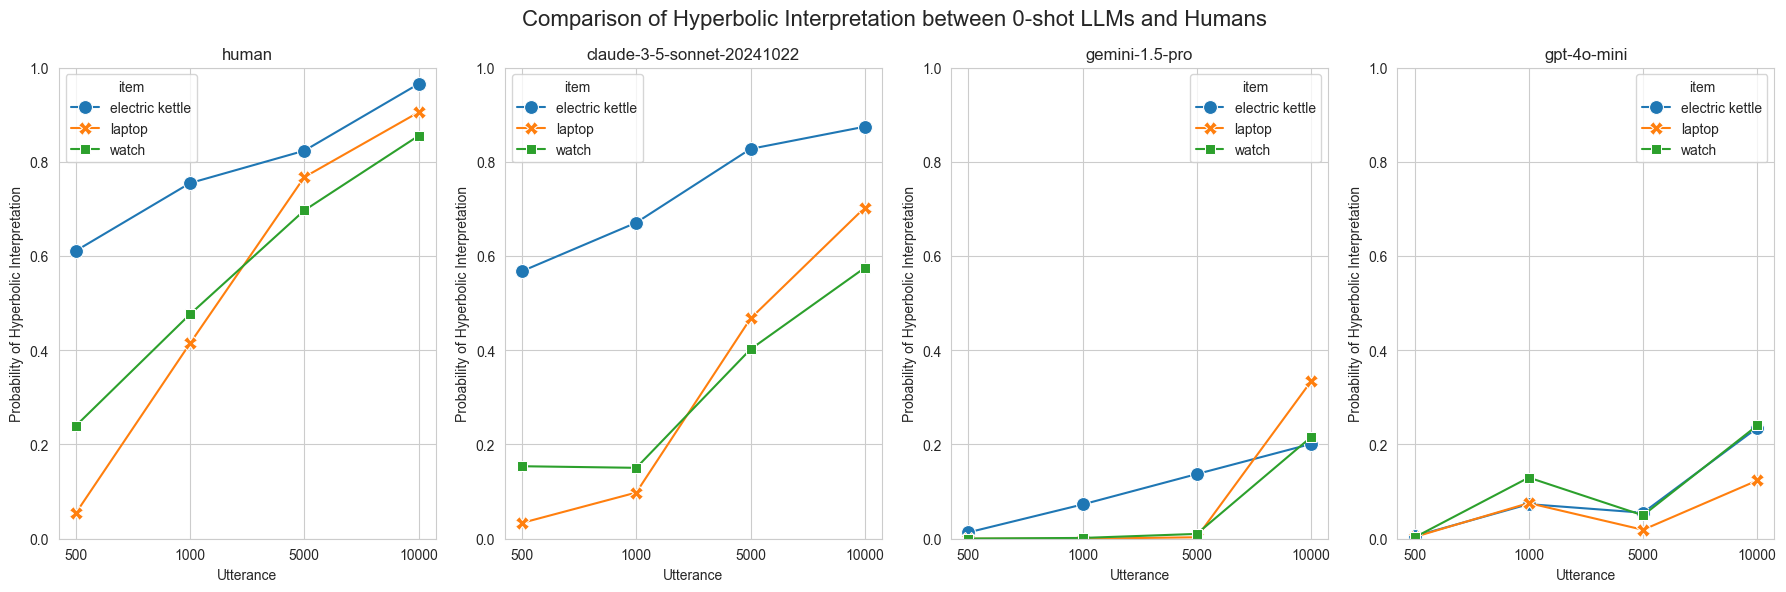

In [72]:
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns

# Set the aesthetic style of the plots
sns.set_style("whitegrid")

# Create a figure and an array of subplots with 1 row and 3 columns
fig, axs = plt.subplots(1, 4, figsize=(18, 6))

# Add a title to the figure
fig.suptitle('Comparison of Hyperbolic Interpretation between 0-shot LLMs and Humans', fontsize=16)

for i, m in enumerate(df_hyperbole_3a['model'].unique()):
    filtered_data = df_hyperbole_3a[df_hyperbole_3a['model'] == m]
    # Convert 'utterance' to string
    filtered_data['utterance'] = filtered_data['utterance_rounded'].astype(str)

    # Create the categorical line plot
    sns.lineplot(ax=axs[i], data=filtered_data, x='utterance', y='probability', hue='item', style='item', markers=True, markersize=10, dashes=False)

    # Set plot labels and title
    axs[i].set_xlabel('Utterance')
    axs[i].set_ylabel('Probability of Hyperbolic Interpretation')
    axs[i].set_ylim(0, 1.0)
    axs[i].set_title(m)

# Adjust layout
plt.tight_layout()

# Show the plot
plt.show()


## Figure 3b

In [95]:
import numpy as np 

def std_error(x):
    x = x.dropna()  # Handle missing values
    if len(x) > 1:
        return np.std(x, ddof=1) / np.sqrt(len(x))
    else:
        return 0

In [97]:
# annotate which utterance was mentioned
df_1b_long["utterance_type"] = df_1b_long["uttered_price"].apply(lambda x: "round" if x % 10 == 0 else "sharp")
df_1b_exact_interpretations = df_1b_long[df_1b_long["price_value"] == df_1b_long["uttered_price"]]
# get fuzzy interpretations and average over the states for each utterance
df_1b_fuzzy_interpretations = df_1b_long[(df_1b_long["price_value"] != df_1b_long["uttered_price"]) & (abs(df_1b_long["price_value"] - df_1b_long["uttered_price"]) < 10)].groupby(["model", "temperature", "item", "run", "uttered_price", "utterance_type"]).agg({"probability": "mean"}).reset_index()
# combine 
df_1b_exact_interpretations = df_1b_exact_interpretations.rename(columns={"probability": "exact_probability"})
# join the exact and fuzzy interpretations by model, run, temperature, item, utterance, and utterance_type
df_1b_fuzzy_interpretations = df_1b_fuzzy_interpretations.rename(columns={"probability": "fuzzy_probability"})
df_1b_halo = df_1b_exact_interpretations.merge(df_1b_fuzzy_interpretations, on=["model", "temperature", "item", "run", "uttered_price", "utterance_type"], how="inner")
df_1b_halo["halo_probability"] = df_1b_halo["exact_probability"] - df_1b_halo["fuzzy_probability"]

In [99]:
# get human data
df_experiment1a["utterance_type"] = df_experiment1a["utterance"].apply(lambda x: "round" if x % 10 == 0 else "sharp")
df_experiment1a_exact_interpretations = df_experiment1a[df_experiment1a["state"] == df_experiment1a["utterance"]]
print(len(df_experiment1a_exact_interpretations))
# get fuzzy interpretations and average over the states for each utterance
df_experiment1a_fuzzy_interpretations = df_experiment1a[(df_experiment1a["state"] != df_experiment1a["utterance"]) & (abs(df_experiment1a["state"] - df_experiment1a["utterance"]) < 10)].groupby(["workerID", "domain", "utterance", "utterance_type"]).agg({"stateProb": "mean"}).reset_index()
print(len(df_experiment1a_fuzzy_interpretations))
# combine
df_experiment1a_exact_interpretations = df_experiment1a_exact_interpretations.rename(columns={"stateProb": "exact_probability"})
# join the exact and fuzzy interpretations by model, run, temperature, item, utterance, and utterance_type
df_experiment1a_fuzzy_interpretations = df_experiment1a_fuzzy_interpretations.rename(columns={"stateProb": "fuzzy_probability"})
df_experiment1a_halo = df_experiment1a_exact_interpretations.merge(df_experiment1a_fuzzy_interpretations, on=["workerID", "domain", "utterance", "utterance_type"], how="inner")
df_experiment1a_halo["halo_probability"] = df_experiment1a_halo["exact_probability"] - df_experiment1a_halo["fuzzy_probability"]
# avergae over participants
df_experiment1a_halo_grouped = df_experiment1a_halo.groupby(["domain", "utterance", "utterance_type"]).agg(halo_probability_mean=("halo_probability", "mean"), std_error=("halo_probability", std_error)).reset_index()
df_experiment1a_halo_grouped["model"] = "human"
df_experiment1a_halo_grouped = df_experiment1a_halo_grouped.rename(columns={"domain": "item", "utterance": "uttered_price"})

1800
1800


In [98]:
# aggregate across runs
df_1b_halo_agg = df_1b_halo.groupby(["model", "temperature", "item", "uttered_price", "utterance_type"]).agg(halo_probability_mean=("halo_probability", "mean"), std_error=("halo_probability", std_error)).reset_index()
df_1b_halo_agg

,model,temperature,item,uttered_price,utterance_type,halo_probability_mean,std_error
0,claude-3-5-sonnet-20241022,1.0,electric kettle,50,round,0.357455,0.012984
1,claude-3-5-sonnet-20241022,1.0,electric kettle,51,sharp,-0.329866,0.070250
2,claude-3-5-sonnet-20241022,1.0,electric kettle,500,round,0.018839,0.006122
3,claude-3-5-sonnet-20241022,1.0,electric kettle,501,sharp,-0.266065,0.028255
4,claude-3-5-sonnet-20241022,1.0,electric kettle,1000,round,0.008030,0.003643
...,...,...,...,...,...,...,...
85,gpt-4o-mini,1.0,watch,1001,sharp,0.611396,0.008566
86,gpt-4o-mini,1.0,watch,5000,round,0.817087,0.008697
87,gpt-4o-mini,1.0,watch,5001,sharp,0.626949,0.009030
88,gpt-4o-mini,1.0,watch,10000,round,0.832583,0.009346


In [106]:
# combine 
df_halo = pd.concat([df_1b_halo_agg, df_experiment1a_halo_grouped])
print(df_halo['model'].unique())
# group by utterance type
df_halo_agg = df_halo.groupby(["model", "item", "utterance_type"]).agg(halo_probability_mean=("halo_probability_mean", "mean"), std_error=("std_error", "mean")).reset_index()
df_halo_agg

['claude-3-5-sonnet-20241022' 'gemini-1.5-pro' 'gpt-4o-mini' 'human']


,model,item,utterance_type,halo_probability_mean,std_error
0,claude-3-5-sonnet-20241022,electric kettle,round,0.078292,0.004896
1,claude-3-5-sonnet-20241022,electric kettle,sharp,-0.176838,0.027594
2,claude-3-5-sonnet-20241022,laptop,round,0.189336,0.011866
3,claude-3-5-sonnet-20241022,laptop,sharp,-0.340127,0.014821
4,claude-3-5-sonnet-20241022,watch,round,0.397178,0.018759
5,claude-3-5-sonnet-20241022,watch,sharp,-0.284940,0.032041
6,gemini-1.5-pro,electric kettle,round,0.560089,0.028725
7,gemini-1.5-pro,electric kettle,sharp,-0.139234,0.054146
8,gemini-1.5-pro,laptop,round,0.839566,0.002616
9,gemini-1.5-pro,laptop,sharp,0.012401,0.002971


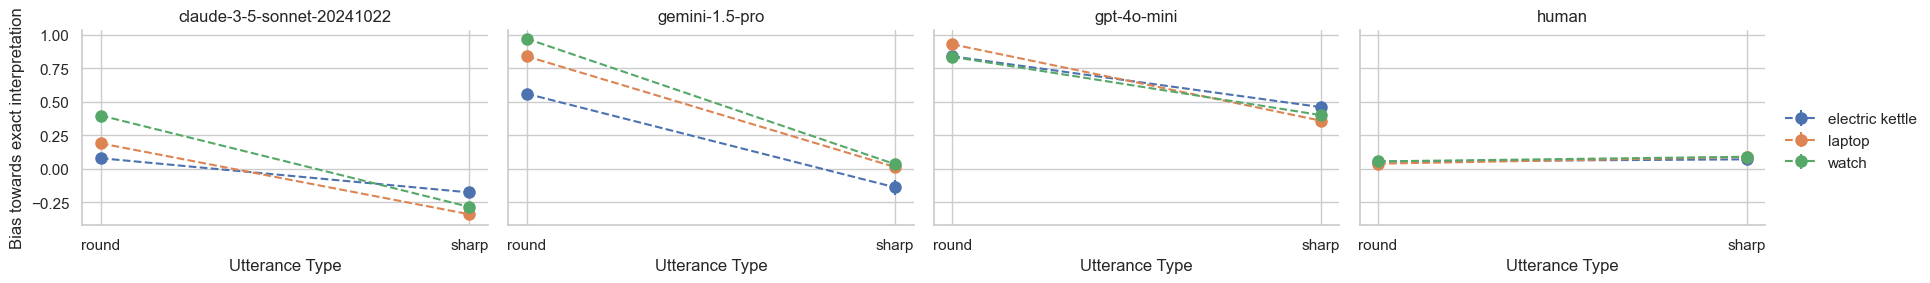

In [108]:
# Set up the facet grid
sns.set(style="whitegrid")
g = sns.FacetGrid(df_halo_agg, col="model", hue="item", sharey=True, sharex=True, aspect=1.5)

# Plot the data
g.map(plt.errorbar, "utterance_type", "halo_probability_mean", "std_error", fmt="o", linestyle="--", markersize=8)

# Customize the appearance
g.set_axis_labels("Utterance Type", "Bias towards exact interpretation")
g.set_titles("{col_name}")
g.add_legend(title="")

# Show the plot
plt.show()


#### Price Prior human

In [106]:
experiment3a_human = pd.read_csv('../../human_data/experiment3a-normalized.csv')

experiment3a_human

# remove workerID, order, stateType, and stateRounded
experiment3a_human = experiment3a_human.drop(columns=['workerID', 'order', 'stateType', 'stateRounded'])

# group by domain then by state and then get the mean of stateProb
experiment3a_human = experiment3a_human.groupby(['domain', 'state']).mean().reset_index()
experiment3a_human
# save the dataframe
# experiment3a_human.to_csv("experiment3a-human.csv", index=False)

,domain,state,stateProb
0,electric kettle,50,0.420496
1,electric kettle,51,0.386461
2,electric kettle,500,0.053286
3,electric kettle,501,0.053754
4,electric kettle,1000,0.022281
5,electric kettle,1001,0.021140
6,electric kettle,5000,0.011161
7,electric kettle,5001,0.011123
8,electric kettle,10000,0.008270
9,electric kettle,10001,0.012029


#### Affect Prior human 

In [107]:
experiment3b_human = pd.read_csv('../../human_data/experiment3b-raw.csv')

experiment3b_human = experiment3b_human.drop(columns=['workerID', 'order',])

# if stateType is sharp, resign the stateRounded number plus one in the same row
experiment3b_human.loc[experiment3b_human['stateType'] == 'sharp', 'stateRounded'] = experiment3b_human['stateRounded'] + 1

# remove the stateType column
experiment3b_human = experiment3b_human.drop(columns=['stateType'])

# rename the stateRounded column to state
experiment3b_human = experiment3b_human.rename(columns={"stateRounded": "state"})

# groupby domain then by state the get the mean of affectProb
experiment3b_human = experiment3b_human.groupby(['domain', 'state']).mean().reset_index()
experiment3b_human
# save the dataframe
# experiment3b_human.to_csv("experiment3b-human.csv", index=False)


,domain,state,affectProb
0,electric kettle,50,0.331250
1,electric kettle,51,0.318333
2,electric kettle,500,0.818333
3,electric kettle,501,0.778571
4,electric kettle,1000,0.915278
5,electric kettle,1001,0.869231
6,electric kettle,5000,0.938235
7,electric kettle,5001,0.969643
8,electric kettle,10000,0.988333
9,electric kettle,10001,0.984722


In [126]:
# LLM 3a and 3b
df_3a_clean_noNa["parsed_response_clean"] = df_3a_clean_noNa["parsed_response_clean"].apply(lambda s: float(s))
# average across runs
df_3a_clean_noNa_summary = df_3a_clean_noNa.groupby(["price", "item", "model"]).mean("parsed_response_clean").reset_index()
# renormalize the probs across prices for each item and each model
df_3a_clean_noNa_summary["normalized_price_prior"] = df_3a_clean_noNa_summary.groupby(["item", "model"])["parsed_response_clean"].transform(lambda x: x/x.sum())

# df_3a_clean_noNa_agg= df_3a_clean_noNa.groupby(["price", "item", "model"]).mean("parsed_response_clean").reset_index()
df_3a_clean_noNa_summary

,price,item,model,is_price_space,price_rounded,closest_price_space,parsed_response_clean,normalized_price_prior
0,50,electric kettle,claude-3-5-sonnet-20241022,1.0,50.0,50.0,0.7050,0.409836
1,50,electric kettle,gemini-1.5-pro,1.0,50.0,50.0,0.7000,0.417661
2,50,electric kettle,gpt-4o-mini,1.0,50.0,50.0,0.7000,0.381783
3,50,laptop,claude-3-5-sonnet-20241022,1.0,50.0,50.0,0.8630,0.203971
4,50,laptop,gemini-1.5-pro,1.0,50.0,50.0,0.9850,0.218597
...,...,...,...,...,...,...,...,...
85,10001,laptop,gemini-1.5-pro,0.0,10000.0,10001.0,0.0990,0.021971
86,10001,laptop,gpt-4o-mini,0.0,10000.0,10001.0,0.0975,0.023514
87,10001,watch,claude-3-5-sonnet-20241022,0.0,10000.0,10001.0,0.0700,0.019746
88,10001,watch,gemini-1.5-pro,0.0,10000.0,10001.0,0.0860,0.031353


In [129]:
df_3a_clean_noNa_summary[df_3a_clean_noNa_summary["model"] == "gpt-4o-mini"]
# df_3a_clean_noNa_summary.to_csv("../../data/llm_proce_prior_summary.csv", index=False)

,price,item,model,is_price_space,price_rounded,closest_price_space,parsed_response_clean,normalized_price_prior
2,50,electric kettle,gpt-4o-mini,1.0,50.0,50.0,0.7000,0.381783
5,50,laptop,gpt-4o-mini,1.0,50.0,50.0,0.8100,0.195345
8,50,watch,gpt-4o-mini,1.0,50.0,50.0,0.7100,0.215970
11,51,electric kettle,gpt-4o-mini,0.0,50.0,51.0,0.6075,0.331334
14,51,laptop,gpt-4o-mini,0.0,50.0,51.0,0.6000,0.144700
17,51,watch,gpt-4o-mini,0.0,50.0,51.0,0.6175,0.187833
20,500,electric kettle,gpt-4o-mini,1.0,500.0,500.0,0.1050,0.057268
23,500,laptop,gpt-4o-mini,1.0,500.0,500.0,0.7000,0.168817
26,500,watch,gpt-4o-mini,1.0,500.0,500.0,0.4200,0.127757
29,501,electric kettle,gpt-4o-mini,0.0,500.0,501.0,0.1450,0.079084


In [121]:
# LLM 3a and 3b
df_3b_clean_noNa["parsed_response_clean"] = df_3b_clean_noNa["parsed_response_clean"].apply(lambda s: float(s))
df_3b_clean_noNa_summary = df_3b_clean_noNa.groupby(["price", "item", "model"]).mean("parsed_response_clean").reset_index()
df_3b_clean_noNa_summary

,price,item,model,is_price_space,price_rounded,closest_price_space,parsed_response,parsed_response_clean
0,50,electric kettle,claude-3-5-sonnet-20241022,1.0,50.0,50.0,0.3950,0.3950
1,50,electric kettle,gemini-1.5-pro,1.0,50.0,50.0,0.2000,0.2000
2,50,electric kettle,gpt-4o-mini,1.0,50.0,50.0,0.3850,0.3850
3,50,laptop,claude-3-5-sonnet-20241022,1.0,50.0,50.0,0.0440,0.0440
4,50,laptop,gemini-1.5-pro,1.0,50.0,50.0,0.0460,0.0460
...,...,...,...,...,...,...,...,...
85,10001,laptop,gemini-1.5-pro,0.0,10000.0,10001.0,0.9500,0.9500
86,10001,laptop,gpt-4o-mini,0.0,10000.0,10001.0,0.9975,0.9975
87,10001,watch,claude-3-5-sonnet-20241022,0.0,10000.0,10001.0,0.9680,0.9680
88,10001,watch,gemini-1.5-pro,0.0,10000.0,10001.0,0.9500,0.9500


In [122]:
# df_3b_clean_noNa_summary.to_csv("../../data/llm_affect_prior_summary.csv", index=False)

In [130]:
df_3b_clean_noNa_summary[df_3b_clean_noNa_summary["model"] == "gpt-4o-mini"]

,price,item,model,is_price_space,price_rounded,closest_price_space,parsed_response,parsed_response_clean
2,50,electric kettle,gpt-4o-mini,1.0,50.0,50.0,0.3850,0.3850
5,50,laptop,gpt-4o-mini,1.0,50.0,50.0,0.1000,0.1000
8,50,watch,gpt-4o-mini,1.0,50.0,50.0,0.2050,0.2050
11,51,electric kettle,gpt-4o-mini,0.0,50.0,51.0,0.5000,0.5000
14,51,laptop,gpt-4o-mini,0.0,50.0,51.0,0.2700,0.2700
17,51,watch,gpt-4o-mini,0.0,50.0,51.0,0.3350,0.3350
20,500,electric kettle,gpt-4o-mini,1.0,500.0,500.0,0.9050,0.9050
23,500,laptop,gpt-4o-mini,1.0,500.0,500.0,0.3950,0.3950
26,500,watch,gpt-4o-mini,1.0,500.0,500.0,0.8000,0.8000
29,501,electric kettle,gpt-4o-mini,0.0,500.0,501.0,0.9000,0.9000
